# Figure 4 · Drug-class-specific OOD behavior and mechanistic context

> One figure, one notebook. Fig4 does not retrain models; it reads redesigned mechanism intermediate tables produced by `fig4_compute.py` and builds explanatory panels A–D. Path discovery, palette, single-panel + combined-figure style match Fig1–Fig3.

## Unifying logic

Fig4's core philosophy: **do not debate abstract model quality; talk concrete biological mechanisms.**

- **Phenomenal layer** — show dual heterogeneity across classes in evaluation bias and model gain.
  - **4A｜Random-CV optimism** — who is most inflated by random CV? Emphasize NNRTI vs PI.
  - **4B｜ESM OOD gain** — where does ESM embedding OOD gain concentrate? Emphasize NRTI/INI vs PI/NNRTI.
- **Mechanistic layer** — use phenotype tails and high-resistance DRM burden to explain why the heterogeneity arises.
  - **4C｜High-FC phenotype tail** — do NNRTI drugs have a heavier high fold-change phenotype tail?
  - **4D｜High-FC DRM burden** — how many drug-major DRMs do `FC>50` high-resistance records carry on average, distinguishing multi-mutation high-barrier PI context from low-DRM switch-like NNRTI effects.

Goal: Fig4 shifts from "model performance differences" to "why drug classes behave differently". This figure only explains mechanistic context; it does not replace Fig3's primary evaluation conclusions.


In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "results" / "notebooks" / "fig4").exists() else CWD.parent
OUT_DIR = PROJECT_ROOT / "results" / "notebooks" / "fig4"
FIG_DIR = PROJECT_ROOT / "figures" / "manuscript" / "fig4"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

DRUG_METRICS = OUT_DIR / "fig4_mechanism_drug_metrics.csv"
FC_TESTS = OUT_DIR / "fig4_fc_threshold_class_tests.csv"
SUMMARY_STATS = OUT_DIR / "fig4_summary_stats.csv"

CLASS_ORDER = ["PI", "NRTI", "NNRTI", "INI"]
# Okabe-Ito-style class palette, distinct on light background.
CLASS_COLOR = {"PI": "#0072B2", "NRTI": "#E69F00", "NNRTI": "#009E73", "INI": "#CC79A7"}
CLASS_MARKER = {"PI": "o", "NRTI": "s", "NNRTI": "^", "INI": "D"}
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
ACCENT, WARN = "#2a78d6", "#d55e00"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK2,
    "text.color": INK,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.grid": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def require(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path}. Run fig4_compute.py first.")
    return path

metrics = pd.read_csv(require(DRUG_METRICS))
fc_tests = pd.read_csv(require(FC_TESTS))
summary = pd.read_csv(require(SUMMARY_STATS))

print("fig4 setup ready")
print("metrics:", metrics.shape, "|", DRUG_METRICS.relative_to(PROJECT_ROOT))
print("fc tests:", fc_tests.shape, "|", FC_TESTS.relative_to(PROJECT_ROOT))
print("summary:", summary.shape, "|", SUMMARY_STATS.relative_to(PROJECT_ROOT))

fig4 setup ready
metrics: (23, 49) | results/notebooks/fig4/fig4_mechanism_drug_metrics.csv
fc tests: (30, 26) | results/notebooks/fig4/fig4_fc_threshold_class_tests.csv
summary: (15, 20) | results/notebooks/fig4/fig4_summary_stats.csv


In [2]:
def format_p(p: float | int | None) -> str:
    if p is None or not np.isfinite(p):
        return "p=n/a"
    p = float(p)
    if p < 1e-3:
        return f"p={p:.1e}"
    if p < 0.01:
        return f"p={p:.3f}"
    return f"p={p:.2f}"


def p2stars(p: float | None) -> str:
    if p is None or not np.isfinite(float(p if p is not None else np.nan)):
        return "n.s."
    p = float(p)
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."


def fmt_delta(x: float | int | None, *, signed: bool = True) -> str:
    if x is None or not np.isfinite(x):
        return "n/a"
    return f"{float(x):+.3f}" if signed else f"{float(x):.3f}"


def get_stat(
    summary_df: pd.DataFrame,
    *,
    category: str | None = None,
    metric: str | None = None,
    contrast: str | None = None,
) -> pd.Series:
    d = summary_df.copy()
    if category is not None:
        d = d[d["category"] == category]
    if metric is not None:
        d = d[d["metric"] == metric]
    if contrast is not None:
        d = d[d["contrast"] == contrast]
    if len(d) == 0:
        return pd.Series(dtype=float)
    return d.iloc[0]


def style_axis(ax: plt.Axes, *, zero: bool = False) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(length=3, color=GRID)
    ax.yaxis.grid(True, color=GRID, lw=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    if zero:
        ax.axhline(0, color=INK3, lw=1.0, ls=(0, (3, 3)), zorder=1)


def sig_bracket(ax: plt.Axes, x1: float, x2: float, p_val: float, *,
                extra_head: float = 0.10, tick_frac: float = 0.04,
                color: str = INK2, lw: float = 1.1) -> None:
    """Draw a horizontal significance bracket + stars between x1 and x2.

    The bracket is drawn at (ylim_top - extra_head * y_span) so the calling
    code can reserve space by inflating ylim beforehand.
    """
    lo, hi = ax.get_ylim()
    span = max(hi - lo, 1e-9)
    y = hi - extra_head * span
    tick = tick_frac * span
    ax.plot([x1, x1, x2, x2], [y - tick, y, y, y - tick],
            color=color, lw=lw, solid_capstyle="round", zorder=5, clip_on=False)
    stars = p2stars(p_val)
    label = f"{stars}\n{format_p(p_val)}"
    ax.text((x1 + x2) / 2, y + 0.01 * span,
            label, ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color=color, zorder=5)


def jittered_strip_by_class(
    ax: plt.Axes,
    metrics_df: pd.DataFrame,
    y_col: str,
    *,
    title: str,
    ylabel: str,
    annotation: str | None = None,   # kept for back-compat; ignored if None
    label_drugs: list[str] | None = None,
) -> None:
    rng = np.random.default_rng(42)
    label_drugs = label_drugs or []
    for i, cls in enumerate(CLASS_ORDER):
        d = metrics_df[metrics_df["class"] == cls].copy()
        y = pd.to_numeric(d[y_col], errors="coerce").to_numpy(float)
        good = np.isfinite(y)
        d = d.loc[good]
        y = y[good]
        x = i + rng.uniform(-0.12, 0.12, size=len(y))
        ax.scatter(
            x, y,
            s=54, marker=CLASS_MARKER[cls], color=CLASS_COLOR[cls],
            edgecolor=SURFACE, linewidth=1.15, alpha=0.95, zorder=3, label=cls,
        )
        if len(y):
            mean = float(np.mean(y))
            q1, q3 = np.percentile(y, [25, 75])
            ax.plot([i - 0.23, i + 0.23], [mean, mean],
                    color=INK, lw=1.7, solid_capstyle="round", zorder=4)
            ax.plot([i, i], [q1, q3], color=INK, lw=1.0, alpha=0.65, zorder=3)
        for xx, yy, drug in zip(x, y, d["drug"]):
            if drug in label_drugs:
                ax.text(xx + 0.035, yy, str(drug), fontsize=7.5, color=INK2, va="center")
    ax.set_xticks(range(len(CLASS_ORDER)), CLASS_ORDER)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontweight="bold", pad=10)
    style_axis(ax, zero=True)
    # legacy text annotation (used only when annotation is not None)
    if annotation:
        ax.text(
            0.02, 0.96, annotation,
            transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color=INK2,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=SURFACE,
                      edgecolor=GRID, linewidth=0.8, alpha=0.95),
        )


def save_panel(fig: plt.Figure, filename: str) -> None:
    fig.savefig(FIG_DIR / filename, dpi=220, bbox_inches="tight", facecolor=SURFACE)
    print("saved", FIG_DIR / filename)


In [3]:
# Check key Fig4 stats: these p-values and group means feed panel annotations.
key_rows = summary.loc[
    summary["category"].isin(["random_cv_overestimate", "esm_ood_gain_main", "genetic_barrier_primary"]),
    ["category", "metric", "contrast", "test", "group1", "group2", "group1_mean", "group2_mean", "p"],
].copy()
key_rows["p_label"] = key_rows["p"].map(format_p)
print(key_rows.to_string(index=False))

class_summary = metrics.groupby("class", as_index=False).agg(
    n_drugs=("drug", "nunique"),
    mean_random_optimism=("random_overestimate_esm_lgb", "mean"),
    median_random_optimism=("random_overestimate_esm_lgb", "median"),
    mean_esm_ood_gain=("esm_ood_gain", "mean"),
    median_esm_ood_gain=("esm_ood_gain", "median"),
    median_fc_gt_50=("prop_fc_gt_50", "median"),
)
class_summary.to_csv(OUT_DIR / "fig4_notebook_class_summary.csv", index=False)
print("\nClass-level notebook summary:")
print(class_summary.round(3).to_string(index=False))

               category                      metric                   contrast                 test   group1   group2  group1_mean  group2_mean        p   p_label
      esm_ood_gain_main                esm_ood_gain       NRTI_INI_vs_PI_NNRTI         mannwhitneyu NRTI+INI PI+NNRTI     0.095901    -0.012369 0.000942 p=9.4e-04
      esm_ood_gain_main                esm_ood_gain NRTI_INI_greater_than_zero wilcoxon_signed_rank NRTI_INI      NaN     0.095901          NaN 0.006836   p=0.007
      esm_ood_gain_main                esm_ood_gain PI_NNRTI_greater_than_zero wilcoxon_signed_rank PI_NNRTI      NaN    -0.012369          NaN 0.935303    p=0.94
 random_cv_overestimate random_overestimate_esm_lgb          drug_class_global              kruskal      NaN      NaN          NaN          NaN 0.068546    p=0.07
 random_cv_overestimate random_overestimate_esm_lgb                NNRTI_vs_PI         mannwhitneyu    NNRTI       PI     0.131530     0.009362 0.002020   p=0.002
genetic_barrier_primar

## 4A · Random-CV optimism is drug-class heterogeneous

Define per-drug **Random-CV optimism** as `AUROC(Random, ESM-nonlinear) − AUROC(Subtype OOD, ESM-nonlinear)`. Each point is a drug, jittered by class; black ticks are means, vertical lines are IQRs. The panel stresses that random-split optimism is not uniform—it differs by drug class, with NNRTI clearly higher than PI.


saved /mnt/c/Users/biodancer/Desktop/tmp_hiv/HIV-OOD/figures/manuscript/fig4/fig4A_random_cv_optimism_by_class.png


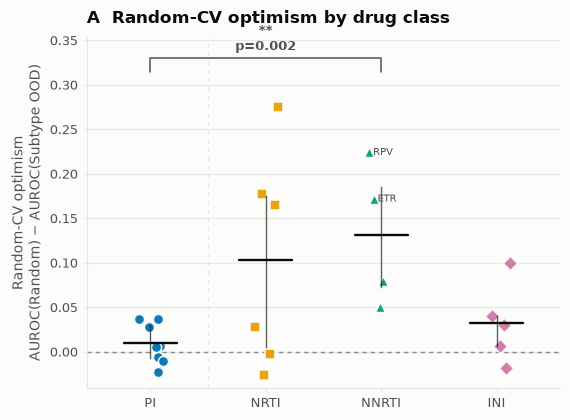

In [4]:
def plot_panel_a(ax: plt.Axes, metrics_df: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    """Class-level random-CV optimism strip with significance bracket."""
    metric = "random_overestimate_esm_lgb"
    label_drugs = ["RPV", "ETR"]
    rng = np.random.default_rng(42)

    # ── draw strip + mean + IQR ───────────────────────────────────────────────
    for i, cls in enumerate(CLASS_ORDER):          # PI=0, NRTI=1, NNRTI=2, INI=3
        d = metrics_df[metrics_df["class"] == cls].copy()
        y = pd.to_numeric(d[metric], errors="coerce").to_numpy(float)
        good = np.isfinite(y)
        d, y = d.loc[good], y[good]
        xj = i + rng.uniform(-0.12, 0.12, size=len(y))
        ax.scatter(xj, y, s=54, marker=CLASS_MARKER[cls], color=CLASS_COLOR[cls],
                   edgecolor=SURFACE, linewidth=1.15, alpha=0.95, zorder=3)
        if len(y):
            mean = float(np.mean(y))
            q1, q3 = np.percentile(y, [25, 75])
            ax.plot([i - 0.23, i + 0.23], [mean, mean],
                    color=INK, lw=1.7, solid_capstyle="round", zorder=4)
            ax.plot([i, i], [q1, q3], color=INK, lw=1.0, alpha=0.65, zorder=3)
        for xx, yy, drug in zip(xj, y, d["drug"]):
            if drug in label_drugs:
                ax.text(xx + 0.035, yy, str(drug), fontsize=7.5, color=INK2, va="center")

    ax.set_xticks(range(4), CLASS_ORDER)
    ax.set_ylabel("Random-CV optimism\nAUROC(Random) − AUROC(Subtype OOD)")
    ax.set_title("A  Random-CV optimism by drug class",
                 loc="left", fontweight="bold", pad=10)
    style_axis(ax, zero=True)
    ax.set_xlim(-0.55, 3.55)

    # thin vertical divider between PI and NRTI
    ax.axvline(0.5, color=GRID, lw=0.9, ls=(0, (3, 4)), zorder=1)

    # ── significance bracket: PI (x=0) vs NNRTI (x=2) only ────────────────────
    pi_y = metrics_df.loc[metrics_df["class"] == "PI",    metric].dropna().to_numpy(float)
    nn_y = metrics_df.loc[metrics_df["class"] == "NNRTI", metric].dropna().to_numpy(float)
    _, p_pi_nnrti = stats.mannwhitneyu(pi_y, nn_y, alternative="less")
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi * 1.22)
    sig_bracket(ax, x1=0, x2=2, p_val=float(p_pi_nnrti), extra_head=0.06, tick_frac=0.04)


fig, ax = plt.subplots(figsize=(5.8, 4.3))
plot_panel_a(ax, metrics, summary)
fig.tight_layout()
save_panel(fig, "fig4A_random_cv_optimism_by_class.png")
plt.show()

## 4B · ESM OOD gains concentrate in NRTI/INI rather than PI/NNRTI

Define per-drug **ESM OOD gain** as `AUROC(Subtype OOD, ESM-nonlinear) − AUROC(Subtype OOD, binary mutation baseline)`. Complements 4A: some classes are more inflated by random CV, but true ESM gains under OOD need not land in the same classes; in the current results, NRTI and INI sit clearly above PI/NNRTI.


saved /mnt/c/Users/biodancer/Desktop/tmp_hiv/HIV-OOD/figures/manuscript/fig4/fig4B_esm_ood_gain_by_class.png


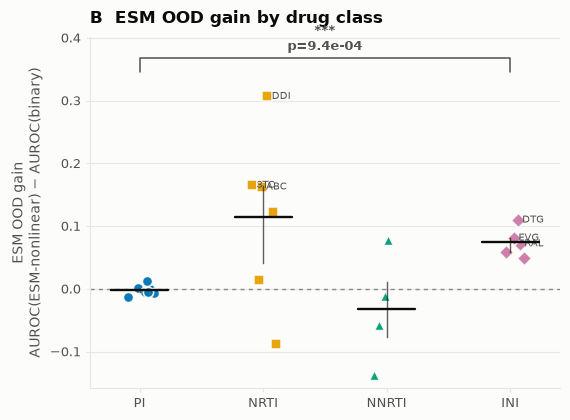

In [5]:
def plot_panel_b(ax: plt.Axes, metrics_df: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    row = get_stat(summary_df, category="esm_ood_gain_main", contrast="NRTI_INI_vs_PI_NNRTI")
    p = row.get("p", np.nan)
    jittered_strip_by_class(
        ax, metrics_df, "esm_ood_gain",
        title="B  ESM OOD gain by drug class",
        ylabel="ESM OOD gain\nAUROC(ESM-nonlinear) − AUROC(binary)",
        annotation=None,
        label_drugs=["DDI", "3TC", "ABC", "DTG", "EVG", "RAL"],
    )
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi * 1.22)
    sig_bracket(ax, x1=0, x2=3, p_val=p, extra_head=0.06)


fig, ax = plt.subplots(figsize=(5.8, 4.3))
plot_panel_b(ax, metrics, summary)
fig.tight_layout()
save_panel(fig, "fig4B_esm_ood_gain_by_class.png")
plt.show()

## 4C · NNRTI phenotypes have a heavier high-FC tail

Aggregate extreme-phenotype rates by class across the three thresholds `FC>10`, `FC>25`, and `FC>50` from fold-change phenotype reads. This panel supplies phenotype-distribution context for NNRTI random-CV optimism / mechanistic differences.


saved /mnt/c/Users/biodancer/Desktop/tmp_hiv/HIV-OOD/figures/manuscript/fig4/fig4C_fc_high_tail.png


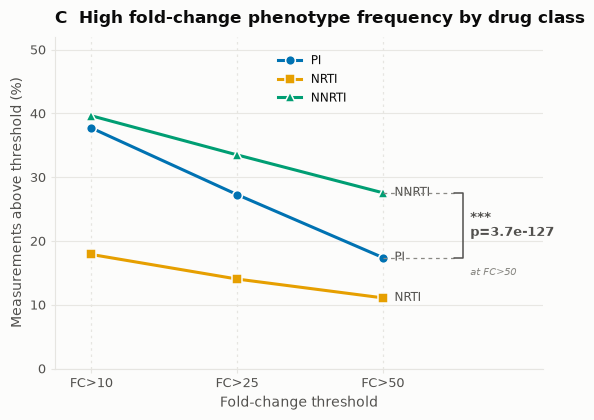

In [6]:
def fc_tail_summary(fc_tests_df: pd.DataFrame) -> pd.DataFrame:
    count_rows = fc_tests_df[fc_tests_df["category"] == "fc_threshold_measurement_count"].copy()
    count_rows = count_rows[count_rows["group1"].isin(["PI", "NRTI", "NNRTI"])]
    count_rows["threshold"] = pd.to_numeric(count_rows["threshold"], errors="coerce")
    count_rows["prop"] = pd.to_numeric(count_rows["group1_mean"], errors="coerce")
    return count_rows.sort_values(["group1", "threshold"])


def plot_panel_d(ax: plt.Axes, fc_tests_df: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    tail = fc_tail_summary(fc_tests_df)
    threshold_pos = {10: 0, 25: 1, 50: 2}
    # collect FC>50 values for significance annotation
    fc50_vals = {}
    for cls in ["PI", "NRTI", "NNRTI"]:
        d = tail[tail["group1"] == cls]
        x_raw = pd.to_numeric(d["threshold"], errors="coerce").to_numpy(float)
        x = np.array([threshold_pos.get(int(v), np.nan) for v in x_raw], dtype=float)
        y = pd.to_numeric(d["prop"], errors="coerce").to_numpy(float)
        good = np.isfinite(x) & np.isfinite(y)
        x, y = x[good], y[good]
        ax.plot(x, y * 100,
                color=CLASS_COLOR[cls], marker=CLASS_MARKER[cls],
                markersize=7.0, linewidth=2.2, label=cls,
                markeredgecolor=SURFACE, markeredgewidth=1.1)
        if len(x) and np.isfinite(y[-1]):
            ax.text(x[-1] + 0.08, y[-1] * 100, cls, color=INK2, fontsize=8.5, va="center")
        # record FC>50 value (last point, x==2)
        fc50 = y[x == 2]
        if len(fc50):
            fc50_vals[cls] = float(fc50[0]) * 100

    for x0 in threshold_pos.values():
        ax.axvline(x0, color=GRID, lw=0.9, ls=(0, (2, 3)), zorder=1)
    ax.set_xticks([0, 1, 2], ["FC>10", "FC>25", "FC>50"])
    ax.set_xlim(-0.25, 3.10)          # extra room on the right for bracket + label
    ax.set_ylim(0, max(52, ax.get_ylim()[1]))
    ax.set_ylabel("Measurements above threshold (%)")
    ax.set_xlabel("Fold-change threshold")
    ax.set_title("C  High fold-change phenotype frequency by drug class",
                 loc="left", fontweight="bold", pad=10)
    style_axis(ax, zero=False)
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(0.62, 0.98))

    # ── significance annotation at FC>50 (NNRTI vs PI) ────────────────────────
    # Bracket is placed to the right of FC>50; dotted leader lines run from the
    # FC>50 data points (x=2) to the bracket, making clear which column is compared.
    row = get_stat(summary_df, category="fc_threshold_measurement_level",
                   contrast="NNRTI_vs_PI_NRTI_fc_gt_50")
    p = row.get("p", np.nan)
    y_nn = fc50_vals.get("NNRTI", np.nan)
    y_pi = fc50_vals.get("PI", np.nan)
    if np.isfinite(y_nn) and np.isfinite(y_pi):
        bx = 2.55          # bracket x-position (right of FC>50 column)
        tick_x = 0.06      # horizontal tick length
        mid_y = (y_nn + y_pi) / 2

        # dotted leader lines from FC>50 data points to bracket ticks
        ax.plot([2.0, bx - tick_x], [y_nn, y_nn],
                color=INK3, lw=0.9, ls=(0, (3, 3)), zorder=4)
        ax.plot([2.0, bx - tick_x], [y_pi, y_pi],
                color=INK3, lw=0.9, ls=(0, (3, 3)), zorder=4)

        # vertical bracket
        ax.plot([bx - tick_x, bx, bx, bx - tick_x],
                [y_nn, y_nn, y_pi, y_pi],
                color=INK2, lw=1.1, solid_capstyle="round", zorder=5)

        # p-value + stars
        label = f"{p2stars(p)}\n{format_p(p)}"
        ax.text(bx + 0.05, mid_y, label,
                ha="left", va="center", fontsize=9.0,
                fontweight="bold", color=INK2, zorder=5)

        # "at FC>50" sub-label below the p-value to anchor the comparison
        ax.text(bx + 0.05, min(y_nn, y_pi) - 1.5, "at FC>50",
                ha="left", va="top", fontsize=7.5, color=INK3,
                style="italic", zorder=5)


fig, ax = plt.subplots(figsize=(5.8, 4.3))
plot_panel_d(ax, fc_tests, summary)
fig.tight_layout()
save_panel(fig, "fig4C_fc_high_tail.png")
plt.show()

## 4D · PI high resistance requires more major DRM sites than NNRTI

Directly contrast genetic barrier between two classes with a **1-D grouped scatter**: each point is a drug.

- **Y-axis (only axis)**: among FC>50 high-resistance records, mean fraction of that drug's major-DRM site list hit (0–1). Normalization removes list-length differences (PI 5–11 sites, NNRTI 7–10 sites).
- **X-axis**: class grouping only (PI / NNRTI); no quantitative scale.
- Horizontal line = within-class median; shade = 95% bootstrap CI; drug names labeled next to points.
- Immediate takeaway: **all PI above (0.41–0.58), all NNRTI below (0.19–0.30), no group overlap**.

This is the **molecular quantification complement** to genetic-barrier grouping: not a label of “high barrier”, but a direct measurement—PI high resistance activates nearly half of key sites on average; NNRTI only about a quarter. That explains why NNRTI is more random-CV inflated in 4A (few switch-like mutations leak easily) and why ESM gain is modest for NNRTI in 4B (binary features already capture the few key sites).

**Limits**: major-DRM lists are curated, so conclusions partly restate prior knowledge; drug-level MW tests have pseudoreplication (within-class drugs correlated), p-values are optimistic—focus on effect direction.


Fig4D high-FC DRM burden (loaded from CSV):
class drug  n_valid_fc_records  n_high_fc_records  prop_high_fc_records  mean_drug_major_drm_count_high_fc  mean_drug_major_drm_frac_high_fc
   PI  FPV                3948                412                 0.104                              4.660                             0.518
   PI  ATV                2851                833                 0.292                              4.733                             0.430
   PI  IDV                4093                665                 0.162                              3.161                             0.452
   PI  LPV                3532                995                 0.282                              4.141                             0.414
   PI  NFV                4165                895                 0.215                              2.040                             0.408
   PI  SQV                4153                653                 0.157                              2.920    

saved /mnt/c/Users/biodancer/Desktop/tmp_hiv/HIV-OOD/figures/manuscript/fig4/fig4D_high_fc_drm_burden.png


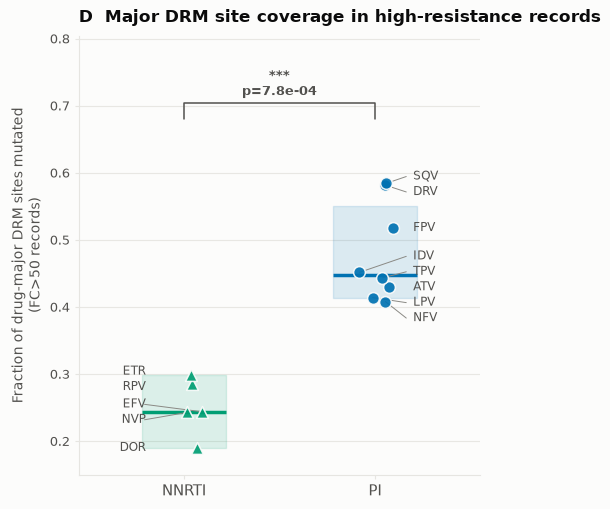

In [7]:
# Load precomputed DRM-burden results (from notebooks/scripts/fig4_compute.py)
fig4e_measurements = pd.read_csv(OUT_DIR / "fig4E_high_fc_drm_burden_measurements.csv")
fig4e_drug         = pd.read_csv(OUT_DIR / "fig4E_high_fc_drm_burden_by_drug.csv")

pi_frac    = fig4e_drug.loc[fig4e_drug["class"] == "PI",    "mean_drug_major_drm_frac_high_fc"].dropna()
nnrti_frac = fig4e_drug.loc[fig4e_drug["class"] == "NNRTI", "mean_drug_major_drm_frac_high_fc"].dropna()
fig4e_p = np.nan
if len(pi_frac) and len(nnrti_frac):
    _, fig4e_p = stats.mannwhitneyu(pi_frac, nnrti_frac, alternative="greater")
print("Fig4D high-FC DRM burden (loaded from CSV):")
print(fig4e_drug[["class", "drug", "n_valid_fc_records", "n_high_fc_records",
                   "prop_high_fc_records", "mean_drug_major_drm_count_high_fc",
                   "mean_drug_major_drm_frac_high_fc"]].round(3).to_string(index=False))
print(f"PI > NNRTI Mann-Whitney p = {fig4e_p:.4g}")


def _spread_labels(ys, min_gap=0.022, iters=200):
    """Push label y-coords apart until no two are closer than min_gap."""
    pos = ys.copy().astype(float)
    for _ in range(iters):
        moved = False
        for i in range(len(pos) - 1):
            gap = pos[i + 1] - pos[i]
            if gap < min_gap:
                shift = (min_gap - gap) / 2.0
                pos[i] -= shift
                pos[i + 1] += shift
                moved = True
        if not moved:
            break
    return pos


def plot_panel_e(ax, fig4e_df):
    """1-D strip: PI vs NNRTI — fraction of drug-major DRM sites mutated (FC>50)."""
    d = fig4e_df.copy()
    d = d[d["class"].isin(["PI", "NNRTI"])].copy()
    d["y"] = pd.to_numeric(d["mean_drug_major_drm_frac_high_fc"], errors="coerce")
    d = d[d["y"].notna()].copy()

    rng = np.random.default_rng(42)
    class_x = {"PI": 1, "NNRTI": 0}
    jitter_w = 0.10

    for cls in ["PI", "NNRTI"]:
        sub = d[d["class"] == cls].sort_values("y").copy()
        cx = class_x[cls]
        jitter = rng.uniform(-jitter_w, jitter_w, size=len(sub))
        sub["xj"] = cx + jitter

        vals = sub["y"].to_numpy()
        bs = np.array([np.median(rng.choice(vals, len(vals), replace=True))
                       for _ in range(2000)])
        lo, hi = np.percentile(bs, [2.5, 97.5])
        med = np.median(vals)

        ax.fill_betweenx([lo, hi], cx - 0.22, cx + 0.22,
                         color=CLASS_COLOR[cls], alpha=0.13, zorder=1)
        ax.hlines(med, cx - 0.22, cx + 0.22,
                  color=CLASS_COLOR[cls], linewidth=2.5, zorder=3)
        ax.scatter(sub["xj"], sub["y"],
                   s=72, color=CLASS_COLOR[cls], marker=CLASS_MARKER[cls],
                   edgecolor=SURFACE, linewidth=1.1, alpha=0.92, zorder=4)

        point_y = sub["y"].to_numpy()
        label_y = _spread_labels(point_y, min_gap=0.023)
        ha = "left" if cls == "PI" else "right"
        lx = cx + 0.20 if cls == "PI" else cx - 0.20
        for py, ly, (_, r) in zip(point_y, label_y, sub.iterrows()):
            if abs(ly - py) > 0.006:
                ax.plot([r["xj"], lx * 0.97 if cls == "PI" else lx * 1.03],
                        [py, ly], color=INK3, lw=0.7, zorder=3, solid_capstyle="round")
            ax.text(lx, ly, r["drug"], fontsize=8.5, color=INK2,
                    va="center", ha=ha, zorder=5)

    # significance bracket between NNRTI (x=0) and PI (x=1)
    pi_v = d.loc[d["class"] == "PI",    "y"].dropna()
    nn_v = d.loc[d["class"] == "NNRTI", "y"].dropna()
    if len(pi_v) and len(nn_v):
        _, p_val = stats.mannwhitneyu(pi_v, nn_v, alternative="greater")
        lo, hi = ax.get_ylim()
        ax.set_ylim(lo, hi * 1.20)
        sig_bracket(ax, x1=0, x2=1, p_val=p_val, extra_head=0.06)

    ax.set_xticks([0, 1], ["NNRTI", "PI"], fontsize=11)
    ax.set_ylabel("Fraction of drug-major DRM sites mutated\n(FC>50 records)", fontsize=10)
    ax.set_title(
        "D  Major DRM site coverage in high-resistance records",
        loc="left", fontweight="bold", pad=10)
    style_axis(ax, zero=False)
    ax.set_xlim(-0.55, 1.55)
    ypad = 0.04
    ax.set_ylim(max(0.0, float(d["y"].min()) - ypad),
                min(1.0, float(d["y"].max()) + ypad + 0.18))


fig, ax = plt.subplots(figsize=(5.0, 5.2))
plot_panel_e(ax, fig4e_drug)
fig.tight_layout()
save_panel(fig, "fig4D_high_fc_drm_burden.png")
plt.show()

## Output artifacts

| Panel | Figure | Table |
|---|---|---|
| 4A | `figures/manuscript/fig4/fig4A_random_cv_optimism_by_class.png` | `fig4_mechanism_drug_metrics.csv`, `fig4_summary_stats.csv` |
| 4B | `figures/manuscript/fig4/fig4B_esm_ood_gain_by_class.png` | `fig4_mechanism_drug_metrics.csv`, `fig4_summary_stats.csv` |
| 4C | `figures/manuscript/fig4/fig4C_fc_high_tail.png` | `fig4_fc_threshold_class_tests.csv`, `fig4_summary_stats.csv` |
| 4D | `figures/manuscript/fig4/fig4D_high_fc_drm_burden.png` | `fig4E_high_fc_drm_burden_by_drug.csv`, `fig4E_high_fc_drm_burden_measurements.csv` |

Suggested caption takeaway: Random-CV optimism and ESM OOD gain are drug-class-specific rather than uniform. NRTI/INI show the clearest ESM OOD gain, whereas NNRTI tasks show stronger random-CV optimism and a heavier high fold-change phenotype tail. Among FC>50 records, PI high resistance carries a higher drug-major DRM burden than NNRTI, supporting a multi-mutation/high-barrier PI context versus a lower-burden NNRTI switch-like phenotype context.

## Combined Figure 4 · panels A–D

Redraw A–D directly from redesigned mechanism intermediate tables and HIVDB Full tables instead of reading single-panel PNGs. This keeps fonts, sizes, line widths, titles, and legend style consistent inside the combined figure; single-panel PNGs remain quick-check artifacts.


saved /mnt/c/Users/biodancer/Desktop/tmp_hiv/HIV-OOD/figures/manuscript/fig4/fig4_combined.png
saved /mnt/c/Users/biodancer/Desktop/tmp_hiv/HIV-OOD/figures/manuscript/fig4/fig4_combined.pdf


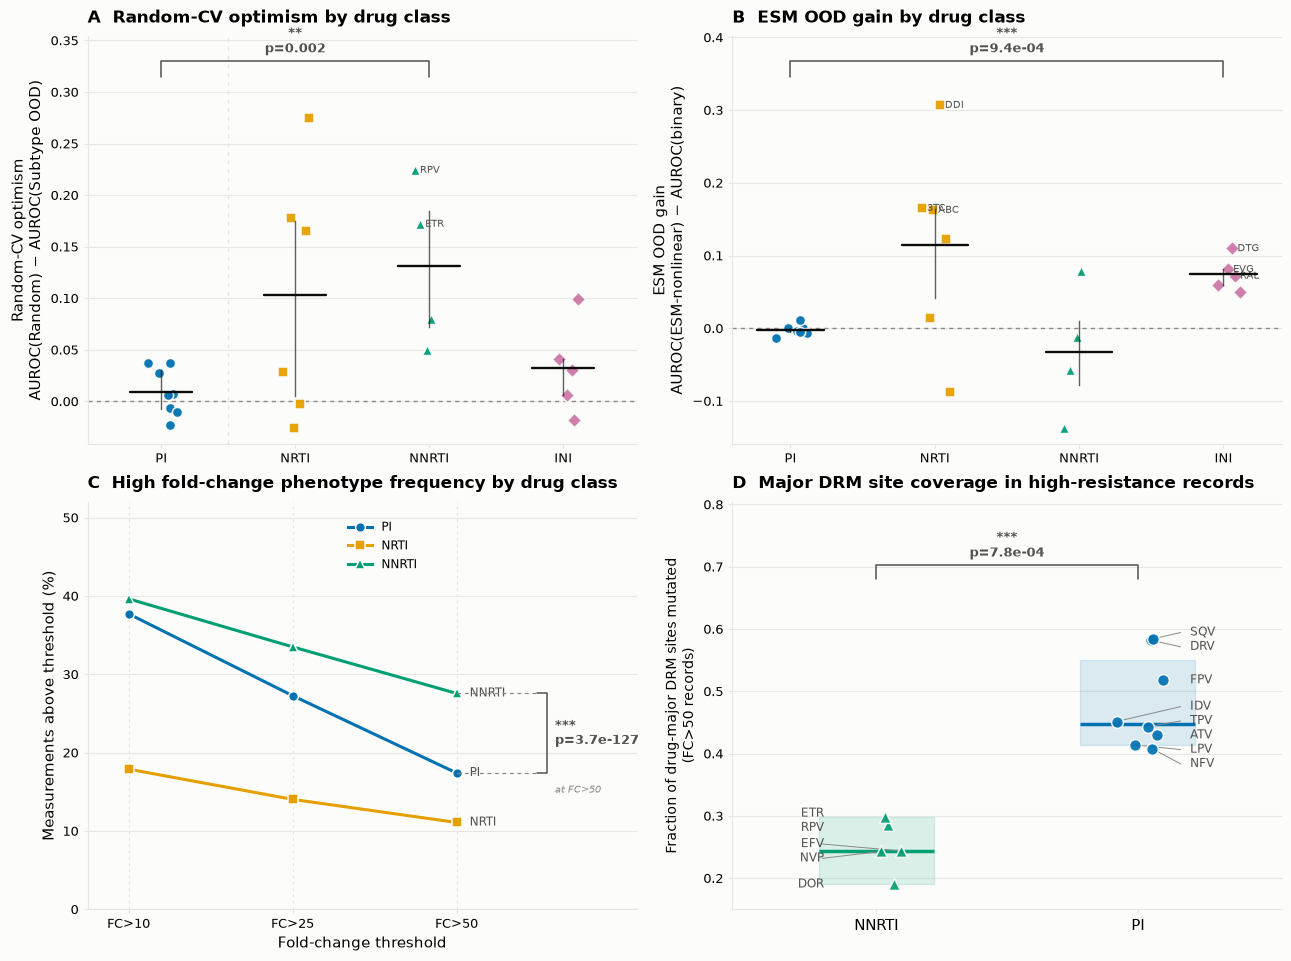

In [8]:
# Combined Figure 4: 4-panel 2×2 layout
# Row 0: A (class optimism) | B (class ESM gain)
# Row 1: C (NNRTI FC tail)  | D (PI DRM burden)
TEXT_COLOR = "#000000"
PANEL_TITLE_SIZE = 12.5
AXIS_LABEL_SIZE = 10.5
TICK_LABEL_SIZE = 9
LEGEND_TEXT_SIZE = 8.5

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": PANEL_TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
    "legend.fontsize": LEGEND_TEXT_SIZE,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
})

fig = plt.figure(figsize=(12.8, 9.5), constrained_layout=True, facecolor=SURFACE)
gs = fig.add_gridspec(2, 2)
ax_a = fig.add_subplot(gs[0, 0])   # A: class optimism
ax_b = fig.add_subplot(gs[0, 1])   # B: class ESM gain
ax_c = fig.add_subplot(gs[1, 0])   # C: NNRTI FC tail
ax_d = fig.add_subplot(gs[1, 1])   # D: PI DRM burden

plot_panel_a(ax_a, metrics, summary)   # A
plot_panel_b(ax_b, metrics, summary)   # B
plot_panel_d(ax_c, fc_tests, summary)  # C (was D)
plot_panel_e(ax_d, fig4e_drug)         # D (was E)

combined_png = FIG_DIR / "fig4_combined.png"
combined_pdf = FIG_DIR / "fig4_combined.pdf"
fig.savefig(combined_png, dpi=240, bbox_inches="tight", facecolor=SURFACE)
fig.savefig(combined_pdf, bbox_inches="tight", facecolor=SURFACE)
print("saved", combined_png)
print("saved", combined_pdf)
plt.show()

In [9]:
# Final artifact check
expected = [
    "fig4_combined.png",
    "fig4_combined.pdf",
    "fig4A_random_cv_optimism_by_class.png",
    "fig4B_esm_ood_gain_by_class.png",
    "fig4C_fc_high_tail.png",
    "fig4D_high_fc_drm_burden.png",
]
for name in expected:
    path = FIG_DIR / name
    print(f"{name}: {'OK' if path.exists() else 'MISSING'}")

fig4_combined.png: OK
fig4_combined.pdf: OK
fig4A_random_cv_optimism_by_class.png: OK
fig4B_esm_ood_gain_by_class.png: OK
fig4C_fc_high_tail.png: OK
fig4D_high_fc_drm_burden.png: OK
